In [97]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.features import cycle
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src._lstm import LSTMRegressor, train_lstm_model
from src.visualization import plot_forecast
from sklearn.metrics import root_mean_squared_error

In [98]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)

    return df

In [99]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [100]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [101]:
target_cols = ['48-1 (0)', '48-1 (1)', '48-1 (2)',
               '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)',
               '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)', '48-1 (11)']
features_cols = ['day_of_year', 'Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [102]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [103]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [104]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [105]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)

In [106]:
input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 128, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model_trial = LSTMRegressor(input_size, hidden_size, num_layers, output_size=output_size).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_model(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=200,
        max_epochs_no_improvement=10,
        verbose=False
    )

    best_val_loss = min(val_hist)
    return best_val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("Лучшие параметры: ", study.best_params)

[I 2026-05-25 01:58:43,553] A new study created in memory with name: no-name-6c5b7964-adf5-4bcb-bca9-564d2f74823e
[I 2026-05-25 01:59:08,168] Trial 0 finished with value: 0.04032448726029344 and parameters: {'hidden_size': 48, 'num_layers': 2, 'lr': 2.6765847759852192e-05}. Best is trial 0 with value: 0.04032448726029344.
[I 2026-05-25 01:59:31,146] Trial 1 finished with value: 0.02542971042010302 and parameters: {'hidden_size': 80, 'num_layers': 1, 'lr': 3.611736805280291e-05}. Best is trial 1 with value: 0.02542971042010302.
[I 2026-05-25 01:59:45,033] Trial 2 finished with value: 0.024425141330136627 and parameters: {'hidden_size': 32, 'num_layers': 3, 'lr': 0.0004962391073701296}. Best is trial 2 with value: 0.024425141330136627.


Early stopping on 101 epoch


[I 2026-05-25 02:00:05,039] Trial 3 finished with value: 0.008304393247197398 and parameters: {'hidden_size': 96, 'num_layers': 1, 'lr': 0.0003933110167723447}. Best is trial 3 with value: 0.008304393247197398.


Early stopping on 184 epoch


[I 2026-05-25 02:00:25,685] Trial 4 finished with value: 0.024206144149959738 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 7.603703594967847e-05}. Best is trial 3 with value: 0.008304393247197398.
[I 2026-05-25 02:00:37,454] Trial 5 finished with value: 0.006599566657503283 and parameters: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.0019925992773592374}. Best is trial 5 with value: 0.006599566657503283.


...

Early stopping on 15 epoch


[I 2026-05-25 02:02:39,858] Trial 18 finished with value: 0.01049358141735766 and parameters: {'hidden_size': 112, 'num_layers': 1, 'lr': 0.0024983650454069094}. Best is trial 15 with value: 0.006263253832480214.


Early stopping on 60 epoch


[I 2026-05-25 02:02:42,504] Trial 19 finished with value: 0.028639548381821055 and parameters: {'hidden_size': 48, 'num_layers': 2, 'lr': 0.00512620547374104}. Best is trial 15 with value: 0.006263253832480214.


Early stopping on 21 epoch
Лучшие параметры:  {'hidden_size': 112, 'num_layers': 1, 'lr': 0.0011196631569179007}


In [107]:
# input_size = full_train_scaled.shape[1]
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=200,
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/200, Train Loss: 0.5820, Val Loss: 0.1204
Epoch 2/200, Train Loss: 0.1360, Val Loss: 0.0746
Epoch 3/200, Train Loss: 0.0844, Val Loss: 0.0486
Epoch 4/200, Train Loss: 0.0494, Val Loss: 0.0396
Epoch 5/200, Train Loss: 0.0282, Val Loss: 0.0302
Epoch 6/200, Train Loss: 0.0227, Val Loss: 0.0290
Epoch 7/200, Train Loss: 0.0254, Val Loss: 0.0299
Epoch 8/200, Train Loss: 0.0190, Val Loss: 0.0384
Epoch 9/200, Train Loss: 0.0251, Val Loss: 0.0215
Epoch 10/200, Train Loss: 0.0328, Val Loss: 0.0252
Epoch 11/200, Train Loss: 0.0377, Val Loss: 0.0456
Epoch 12/200, Train Loss: 0.0280, Val Loss: 0.0305
Epoch 13/200, Train Loss: 0.0126, Val Loss: 0.0246
Epoch 14/200, Train Loss: 0.0134, Val Loss: 0.0211
Epoch 15/200, Train Loss: 0.0111, Val Loss: 0.0241
Epoch 16/200, Train Loss: 0.0099, Val Loss: 0.0219
Epoch 17/200, Train Loss: 0.0097, Val Loss: 0.0217
Epoch 18/200, Train Loss: 0.0090, Val Loss: 0.0215
Epoch 19/200, Train Loss: 0.0106, Val Loss: 0.0205
Epoch 20/200, Train Loss: 0.0093, Val Lo

Test RMSE: 0.8397
RMSE for 48-1 (0): 3.5834


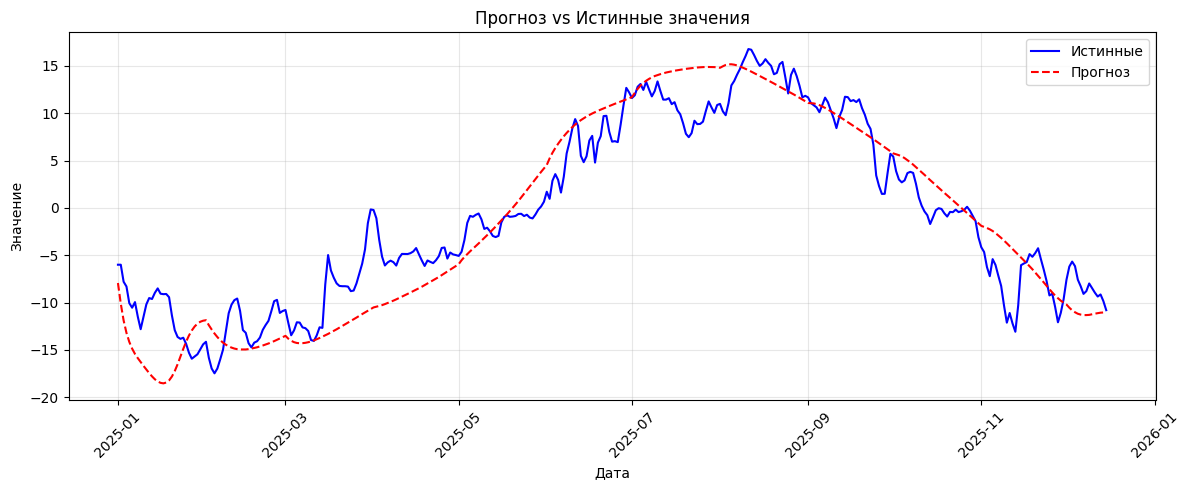

RMSE for 48-1 (1): 1.8114


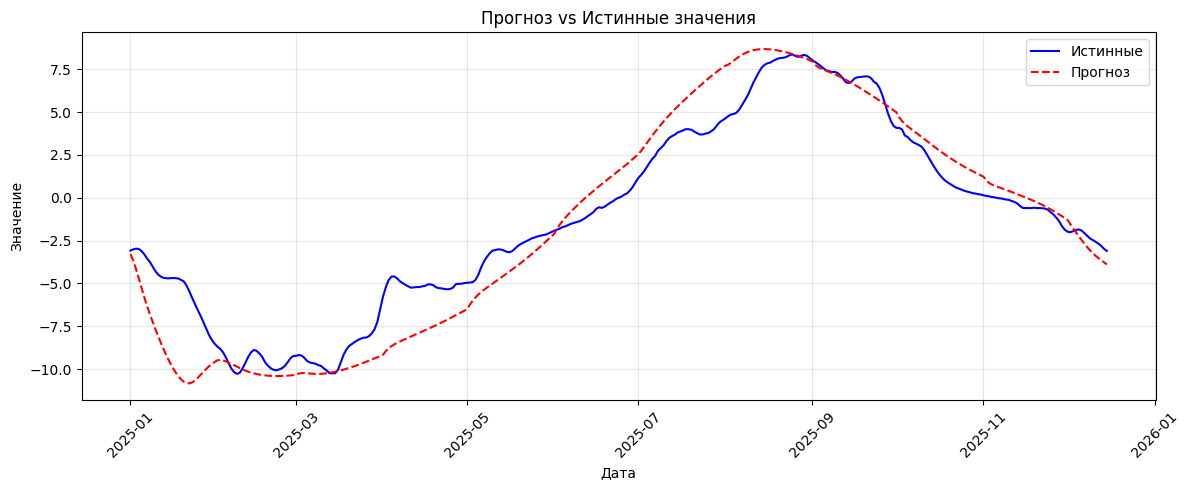

RMSE for 48-1 (2): 1.1445


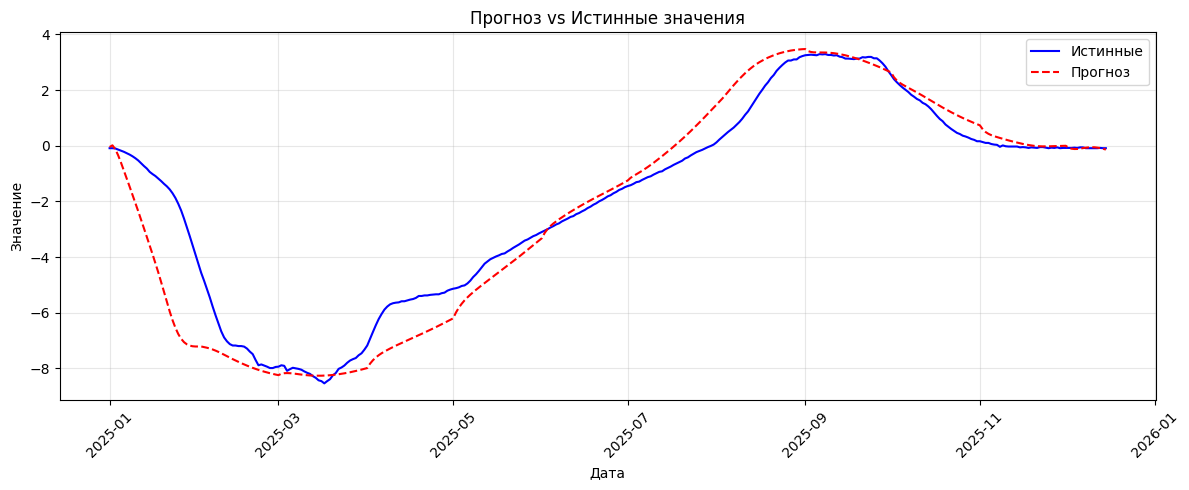

RMSE for 48-1 (3): 0.7038


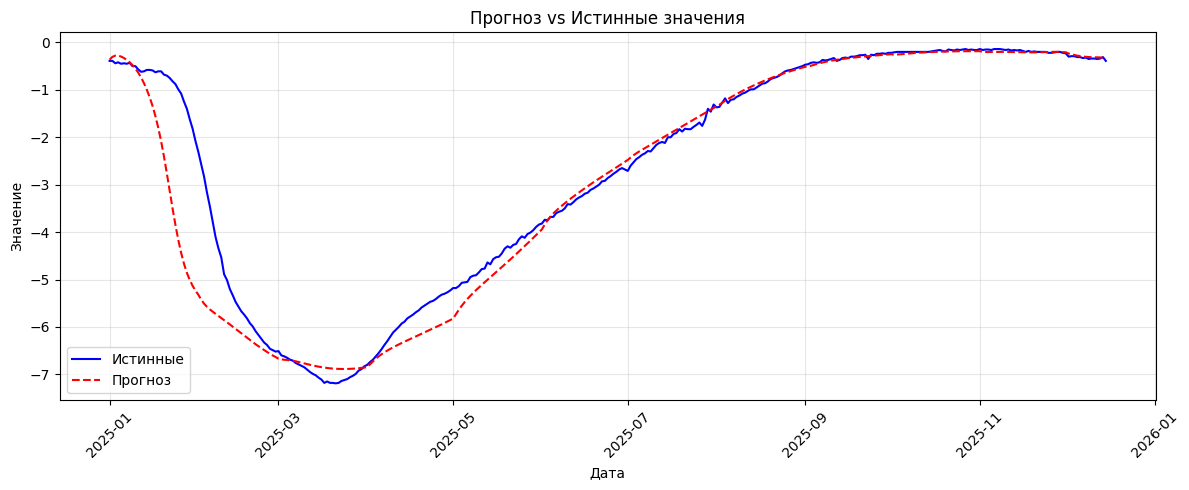

RMSE for 48-1 (4): 0.5034


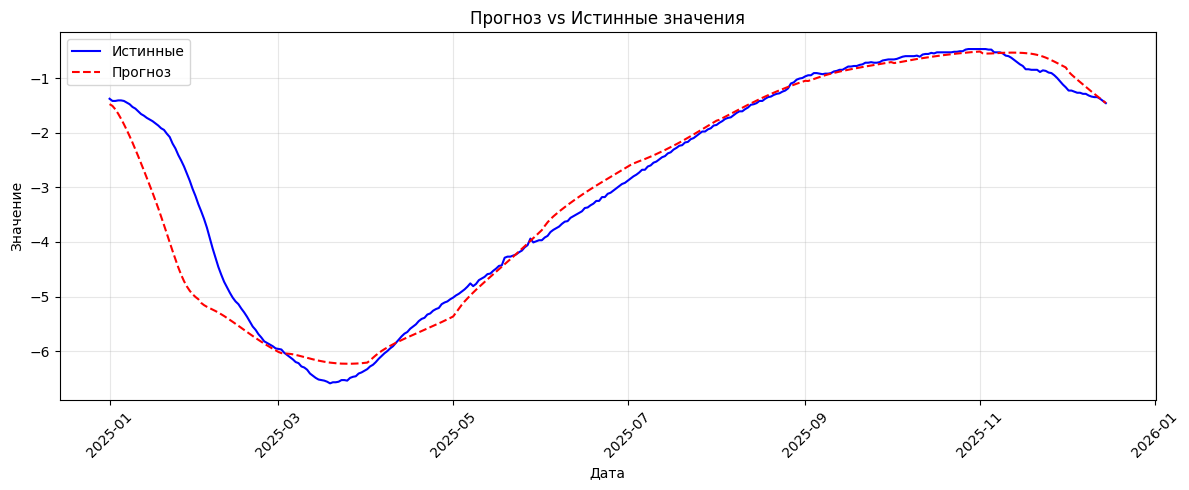

RMSE for 48-1 (5): 0.4519


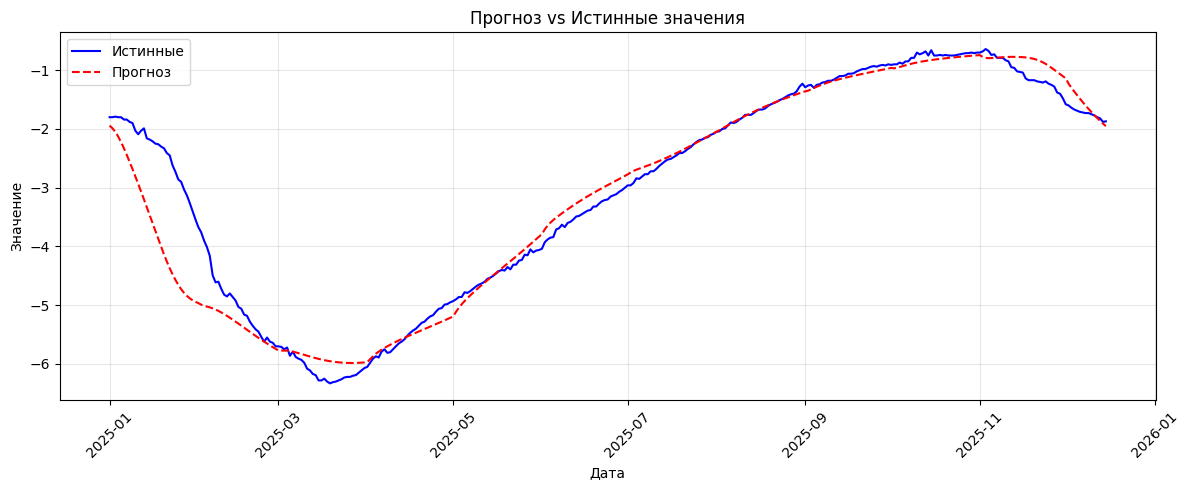

RMSE for 48-1 (6): 0.4349


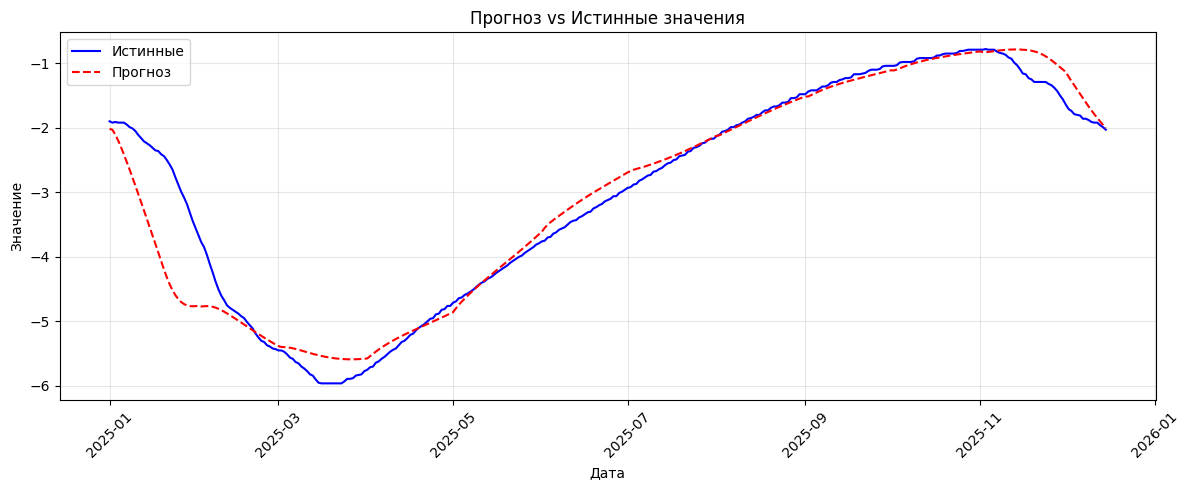

RMSE for 48-1 (7): 0.4148


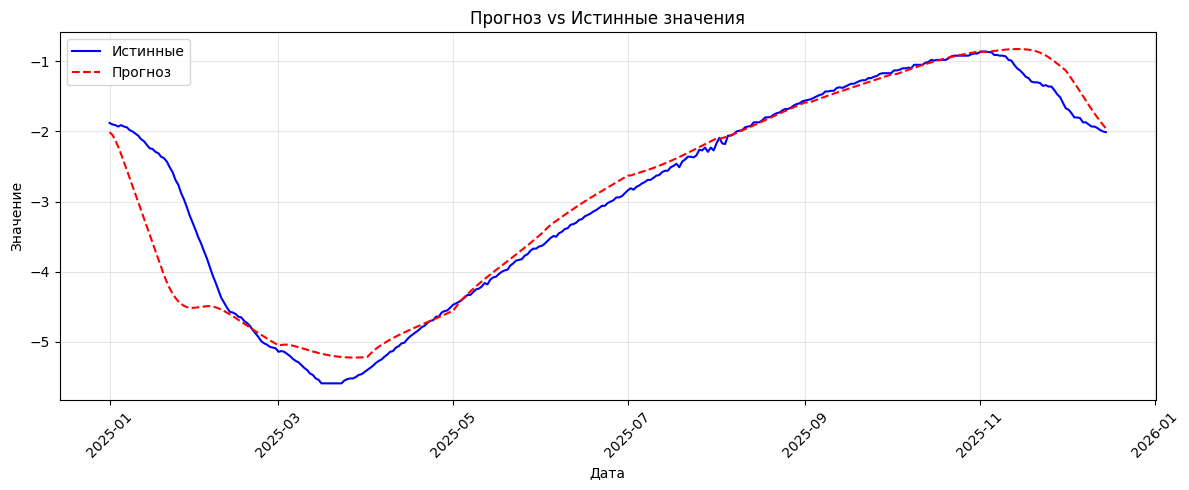

RMSE for 48-1 (8): 0.3580


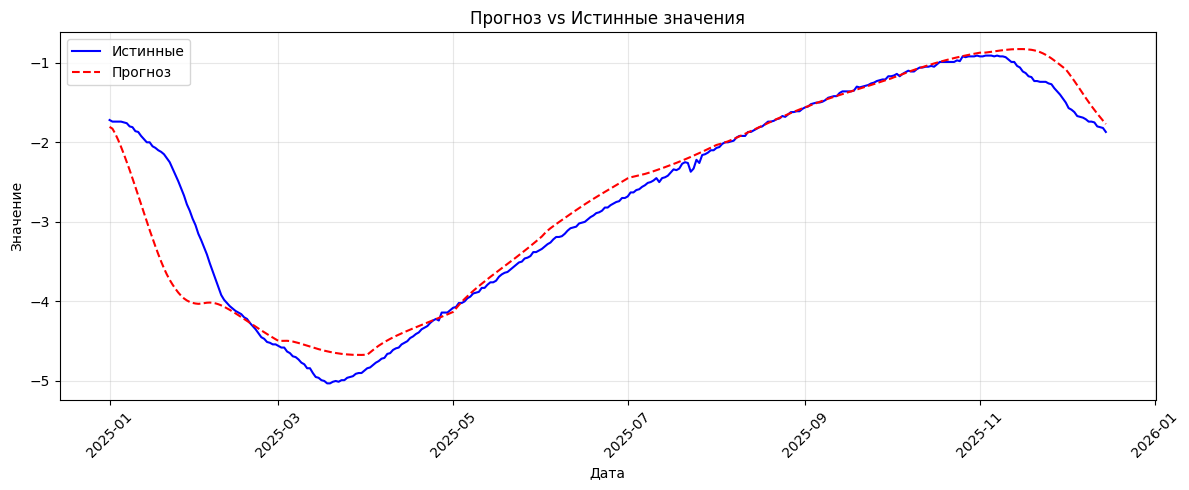

RMSE for 48-1 (9): 0.2803


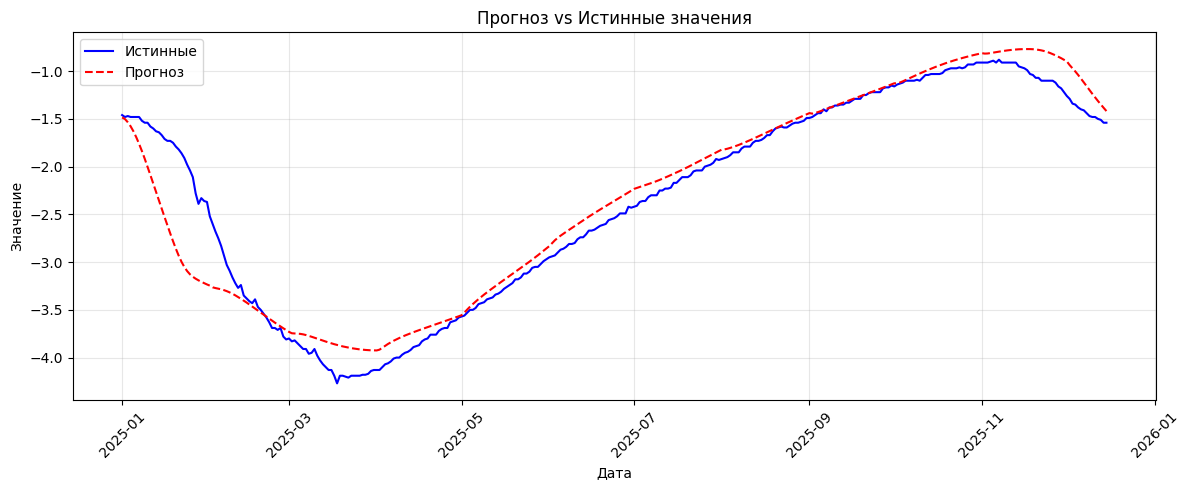

RMSE for 48-1 (10): 0.2116


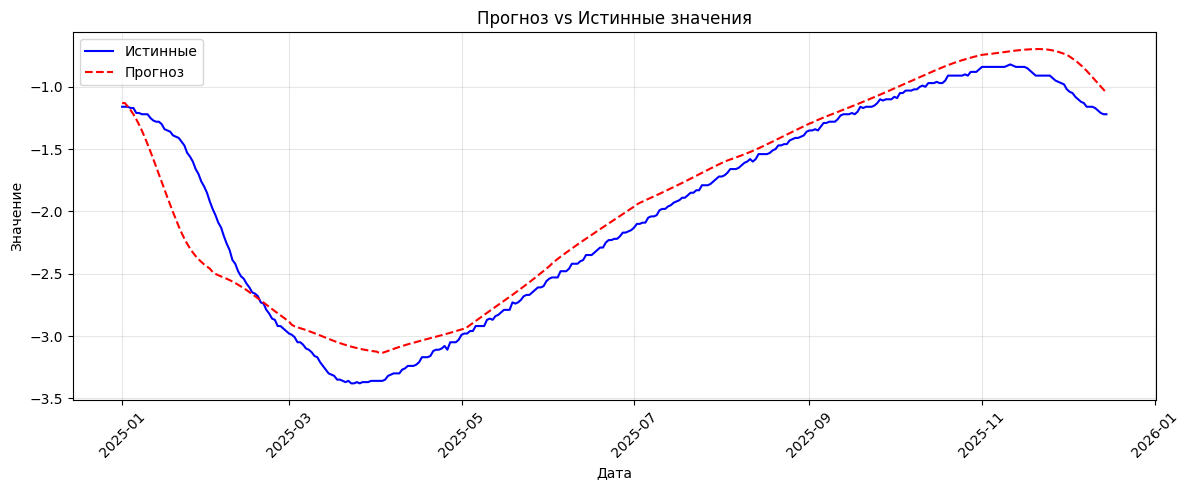

RMSE for 48-1 (11): 0.1786


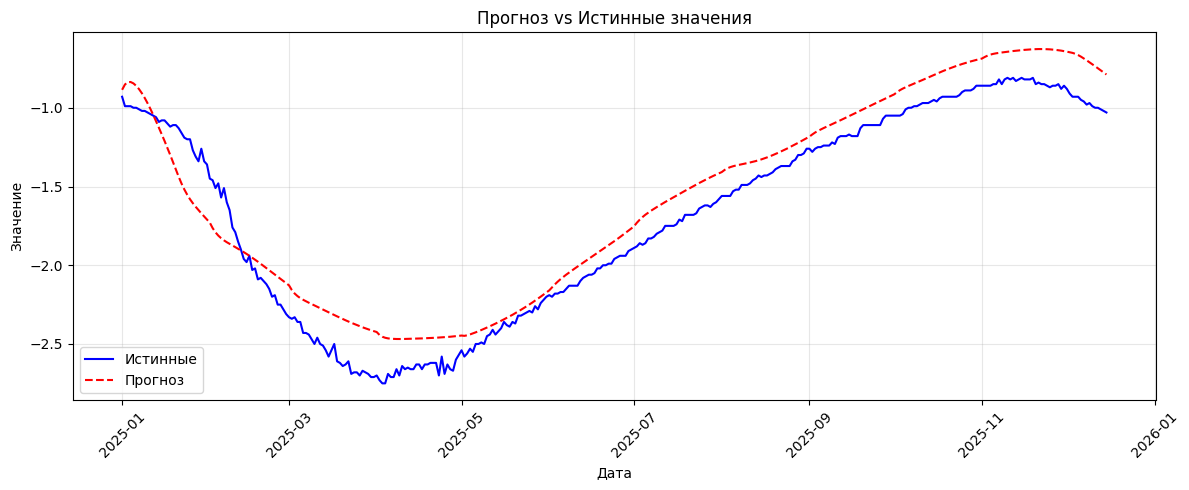

In [108]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

model.eval()
y_pred_scaled = []

with torch.no_grad():
    for i in range(len(df_test)):
        lags_tensor = torch.tensor(current_lags, dtype=torch.float32).unsqueeze(0).to(device)

        pred = model(lags_tensor).cpu().numpy()[0]
        y_pred_scaled.append(pred)

        next_step_features = future_features_scaled[i]

        next_step_vector = np.append(next_step_features, pred)

        current_lags = np.vstack((current_lags[1:], next_step_vector))

y_pred_scaled = np.array(y_pred_scaled)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))

In [119]:
# ранее обученная модель
model = torch.load('models/lstm_v1_2.pth', weights_only=False)

Test RMSE: 0.6725
RMSE for 48-1 (0): 3.1665


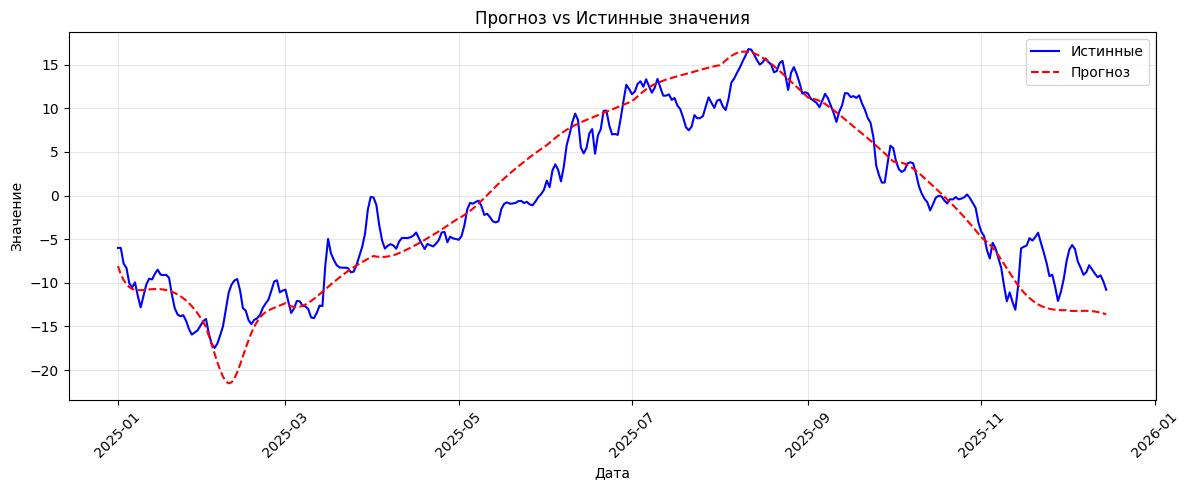

RMSE for 48-1 (1): 1.1253


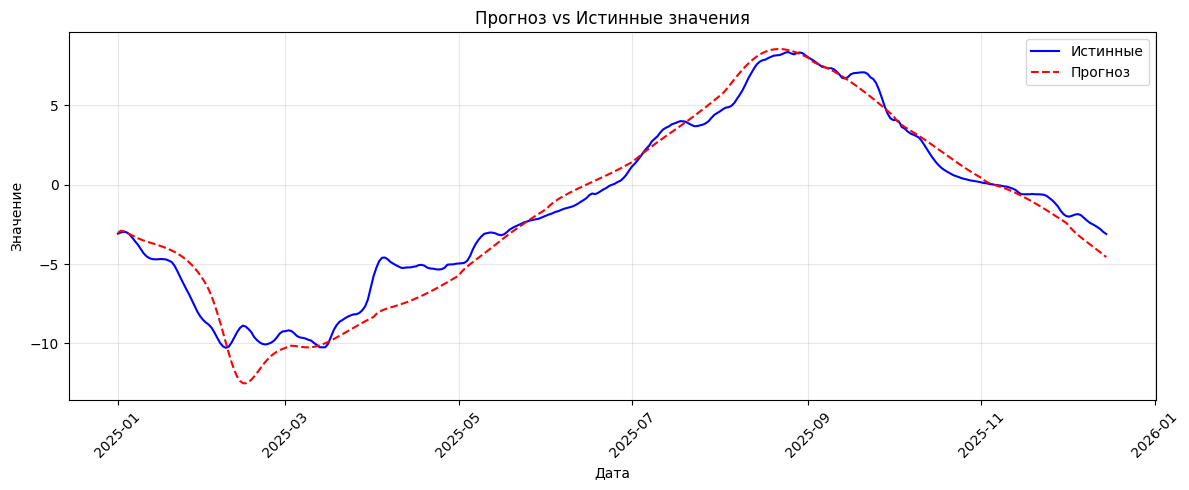

RMSE for 48-1 (2): 0.7538


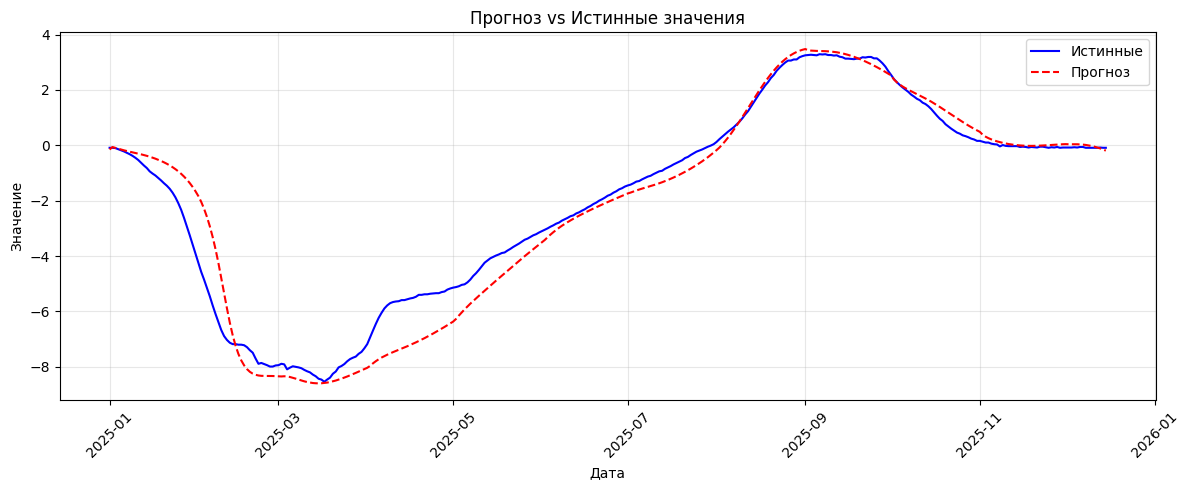

RMSE for 48-1 (3): 0.6199


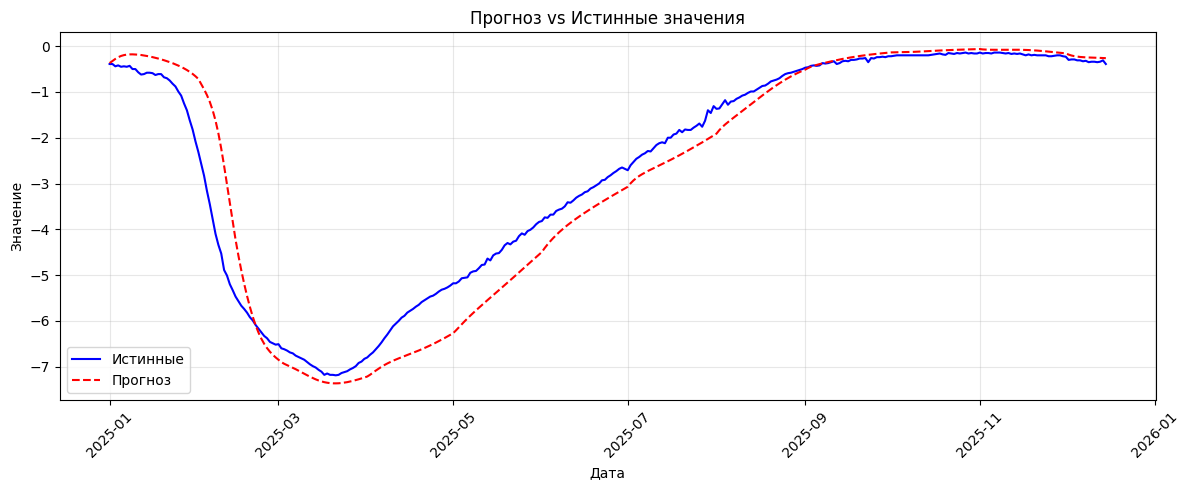

RMSE for 48-1 (4): 0.4445


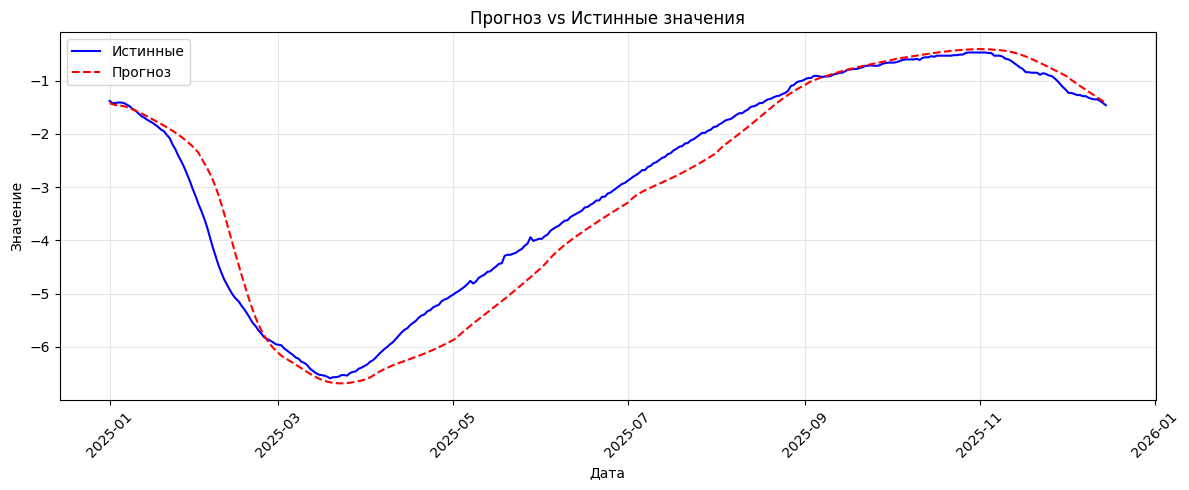

RMSE for 48-1 (5): 0.3895


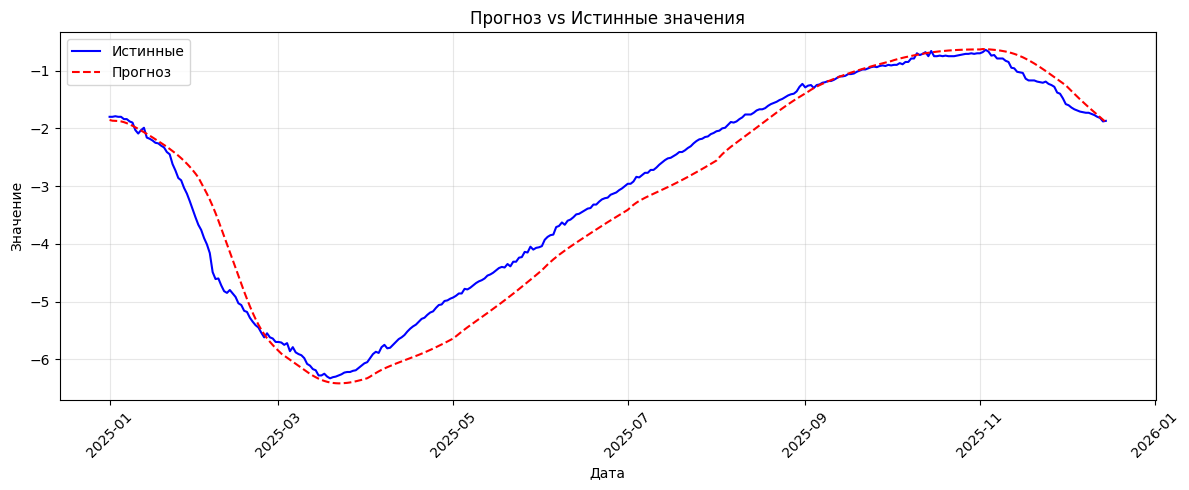

RMSE for 48-1 (6): 0.3761


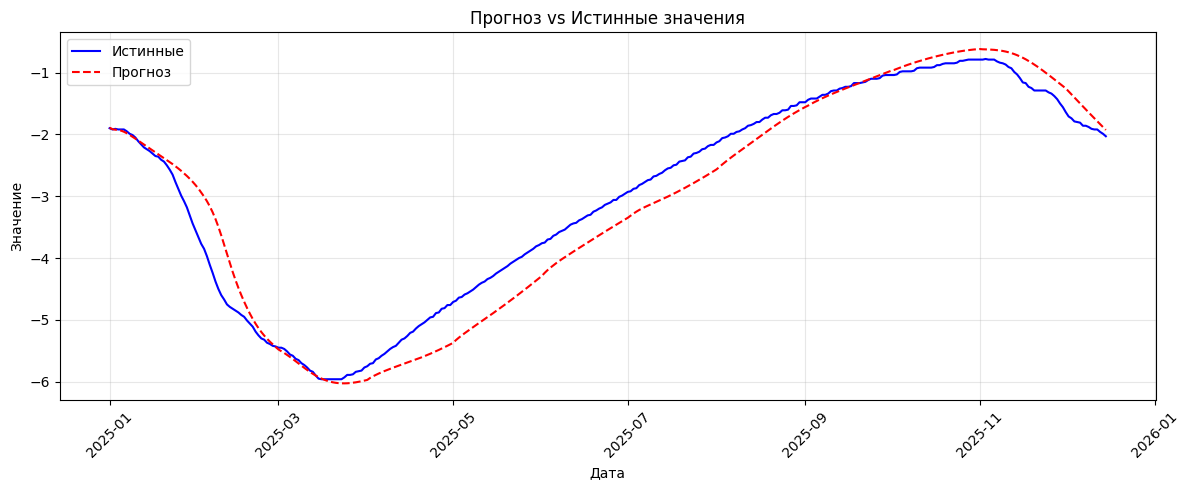

RMSE for 48-1 (7): 0.3242


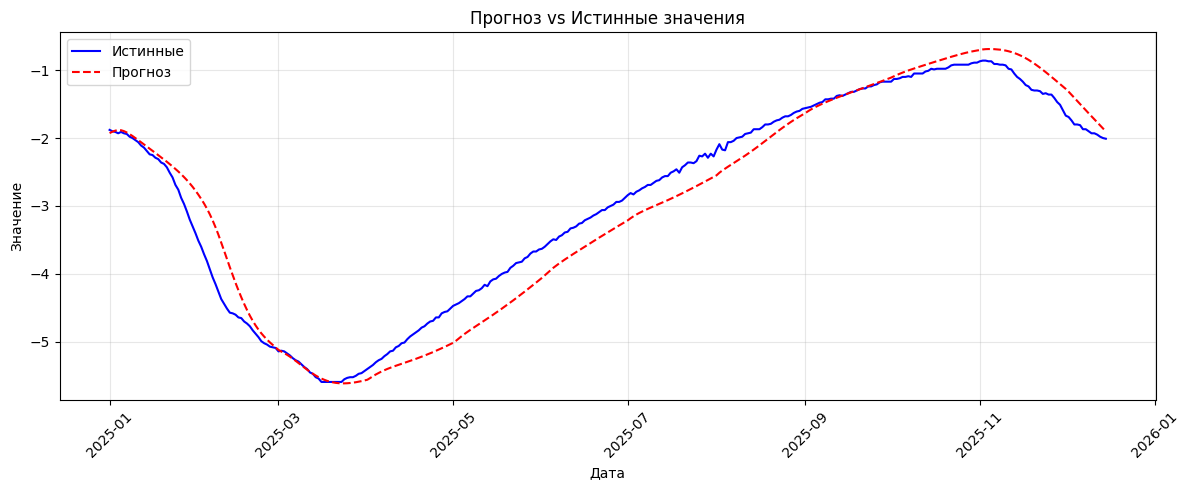

RMSE for 48-1 (8): 0.2907


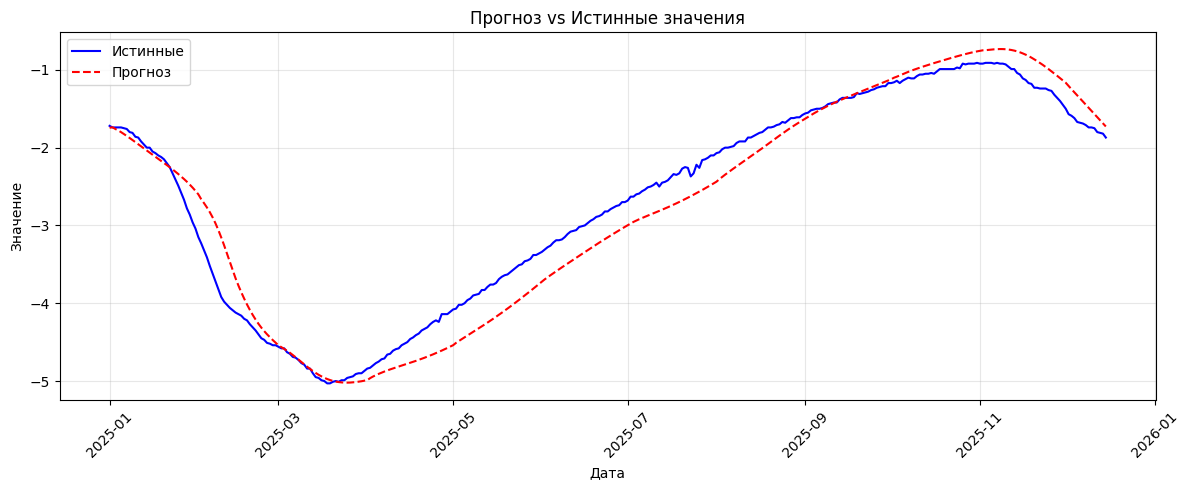

RMSE for 48-1 (9): 0.2430


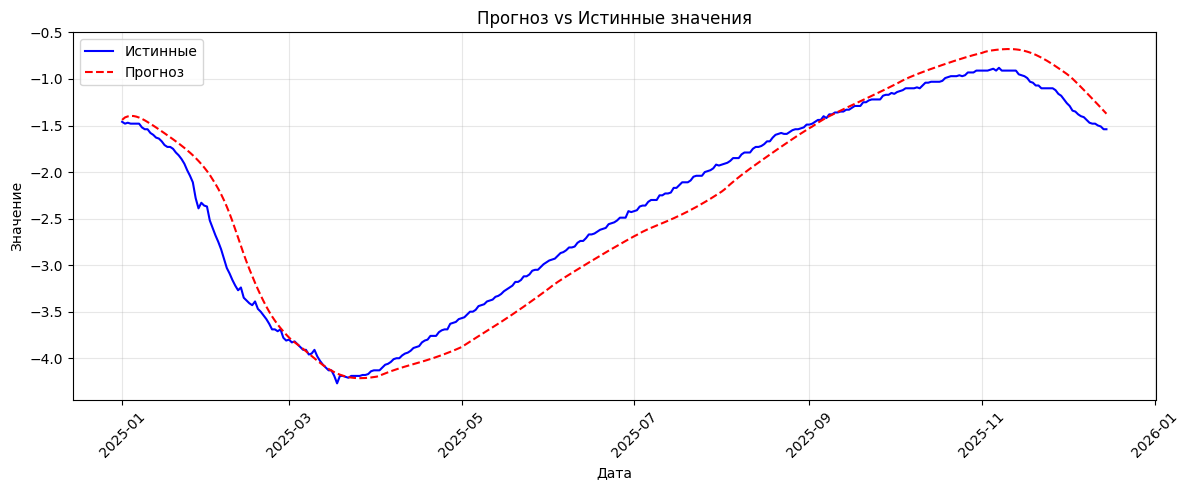

RMSE for 48-1 (10): 0.1813


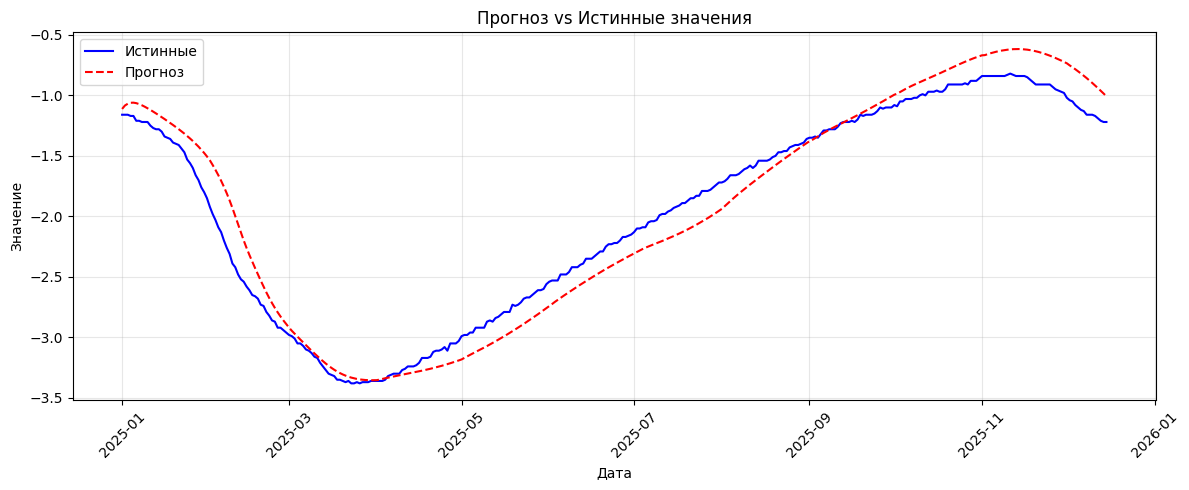

RMSE for 48-1 (11): 0.1549


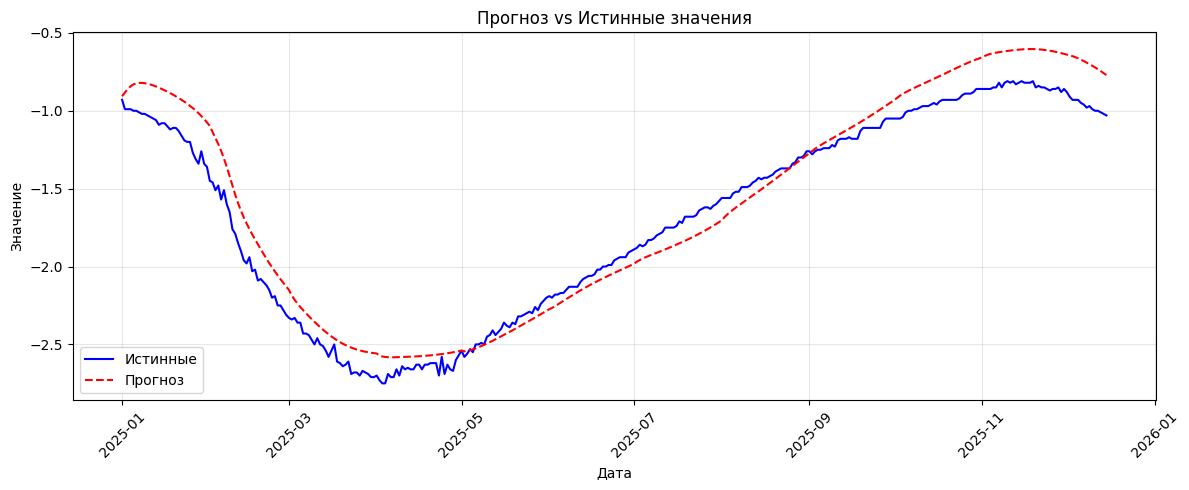

In [120]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

model.eval()
y_pred_scaled = []

with torch.no_grad():
    for i in range(len(df_test)):
        lags_tensor = torch.tensor(current_lags, dtype=torch.float32).unsqueeze(0).to(device)

        pred = model(lags_tensor).cpu().numpy()[0]
        y_pred_scaled.append(pred)

        next_step_features = future_features_scaled[i]

        next_step_vector = np.append(next_step_features, pred)

        current_lags = np.vstack((current_lags[1:], next_step_vector))

y_pred_scaled = np.array(y_pred_scaled)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))